In [1]:
# various import statements
import os
import inspect
import seaborn
import matplotlib
import matplotlib.pyplot as plt
import torch
import scanpy as sc
import pyro

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print("GPU is available")
    print("Number of GPUs:", torch.cuda.device_count())
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available")

import sys
sys.path.append('/home/matthew.schmitz/Matthew/code/scANTIPODE/')
import antipode
from antipode.antipode_model import *
import antipode.model_functions
from antipode.model_functions import *
import antipode.model_distributions
from antipode.model_distributions import *
import antipode.model_modules
from antipode.model_modules import *
import antipode.train_utils
from antipode.train_utils import *
import antipode.plotting
from antipode.plotting import *

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU is available
Number of GPUs: 1
GPU Name: NVIDIA A100-PCIE-40GB


In [2]:
#adata=sc.read_h5ad(os.path.expanduser('/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Matthew/data/taxtest/HvQvM/HvQvMall_cere_clean_nodoublets.h5ad'),backed='r')
adata=sc.read_h5ad(os.path.expanduser('/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Matthew/data/taxtest/HvQvM/HvQvMall_part0.h5ad'))

batch_key='batch_name'
discov_key='species'
layer_key='spliced'

In [3]:
adata=adata[adata.obs['species']!='human',:]
adata.obs['species']=adata.obs['species'].astype(str)
adata=adata.copy()

/scratch/fast/15756057/ipykernel_27701/3045004219.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['species']=adata.obs['species'].astype(str)


In [4]:
num_var=adata.shape[1]
batch_size=32
level_sizes=[1,50,300]
num_latent=200
steps=0
max_steps=20000
print_every=5000

# Clear Pyro param store so we don't conflict with previous run
try:
    pyro.clear_param_store()
    del antipode_model
    torch.cuda.empty_cache()
except:
    pass
# Fix random number seed to a lucky number
pyro.util.set_rng_seed(13)
# Enable optional validation warnings
pyro.enable_validation(False)

model_tag='1.9.1.8.1_2Species'
# Instantiate instance of model/guide and various neural networks
antipode_model = ANTIPODE(num_latent=num_latent,level_sizes=level_sizes,bi_depth=2,num_batch_embed=10,psi_levels=[0.,1.,1.],
                adata=adata,discov_pair=('obs',discov_key),batch_pair=('obs',batch_key),layer=layer_key,
                use_psi=True,use_q_score=True,prior_scale=50.,sampler_category='species',dist_normalize=False,
                scale_init_val=0.01,loc_as_param=False,zdw_as_param=False,intercept_as_param=False,classifier_hidden=[2048,2048,2048],encoder_hidden=[4096,4096,4096])


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:183: UserWarning: Category 198 in adata.obs['_scvi_batch_ind'] has fewer than 3 cells. Models may not train properly.
  categorical_mapping = _make_column_categorical(


# Training Phase 1: Block Approximation

In [12]:
antipode_model.train_phase(phase=1,max_steps=100000,print_every=10000,num_particles=1,device=device, max_learning_rate=0.001, one_cycle_lr=True, steps=0, batch_size=32)

  0%|          | 0/100000 [00:00<?, ?it/s]/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Matthew/code/scANTIPODE/antipode/train_utils.py:282: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if sum(index.shape) == 1:
/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Matthew/code/scANTIPODE/antipode/train_utils.py:285: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  index=torch.nn.functional.one_hot(index.squeeze(),num_classes=out_shape[1]).float() if index.shape[-1]==1 else index
/allen/programs/celltypes/workgroups/rnaseqanal

[Step 10000]  Loss: 0.10006


 20%|██        | 20003/100000 [17:16<1:09:58, 19.05it/s]

[Step 20000]  Loss: 0.10005


 23%|██▎       | 22640/100000 [19:29<1:03:52, 20.18it/s]

...

STEP SKIPPED


 36%|███▋      | 36459/100000 [31:04<54:06, 19.57it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

 40%|████      | 40005/100000 [34:02<50:25, 19.83it/s]  

[Step 40000]  Loss: 0.10004


 48%|████▊     | 47944/100000 [40:41<45:25, 19.10it/s]

KeyboardInterrupt: 

In [13]:
!nvidia-smi
antipode_model.clear_cuda()
!nvidia-smi

Thu Apr 11 15:16:53 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 545.23.08              Driver Version: 545.23.08    CUDA Version: 12.3     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100-PCIE-40GB          On  | 00000000:64:00.0 Off |                    0 |
| N/A   45C    P0              39W / 250W |   8485MiB / 40960MiB |      0%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()
 40%|███▉      | 7990/20000 [1:07:54<1:42:04,  1.96it/s]


Thu Apr 11 15:16:54 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 545.23.08              Driver Version: 545.23.08    CUDA Version: 12.3     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100-PCIE-40GB          On  | 00000000:64:00.0 Off |                    0 |
| N/A   46C    P0              62W / 250W |   4635MiB / 40960MiB |      0%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

In [14]:
antipode_model.store_outputs(device=device,prefix='')

In [15]:
!nvidia-smi
antipode_model.clear_cuda()
!nvidia-smi

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Thu Apr 11 15:17:06 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 545.23.08              Driver Version: 545.23.08    CUDA Version: 12.3     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100-PCIE-40GB          On  | 00000000:64:00.0 Off |                    0 |
| N/A   44C    P0              39W / 250W |   4635MiB / 40960MiB |      0%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

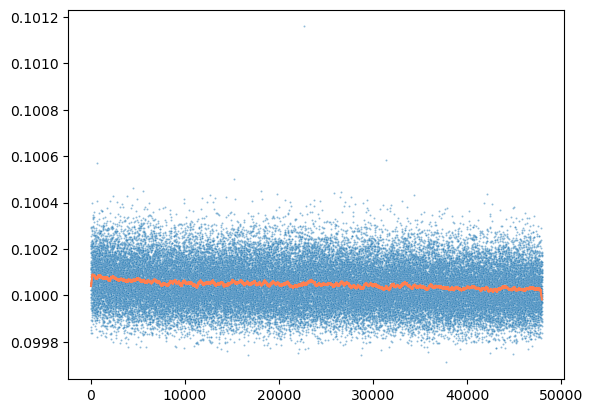

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


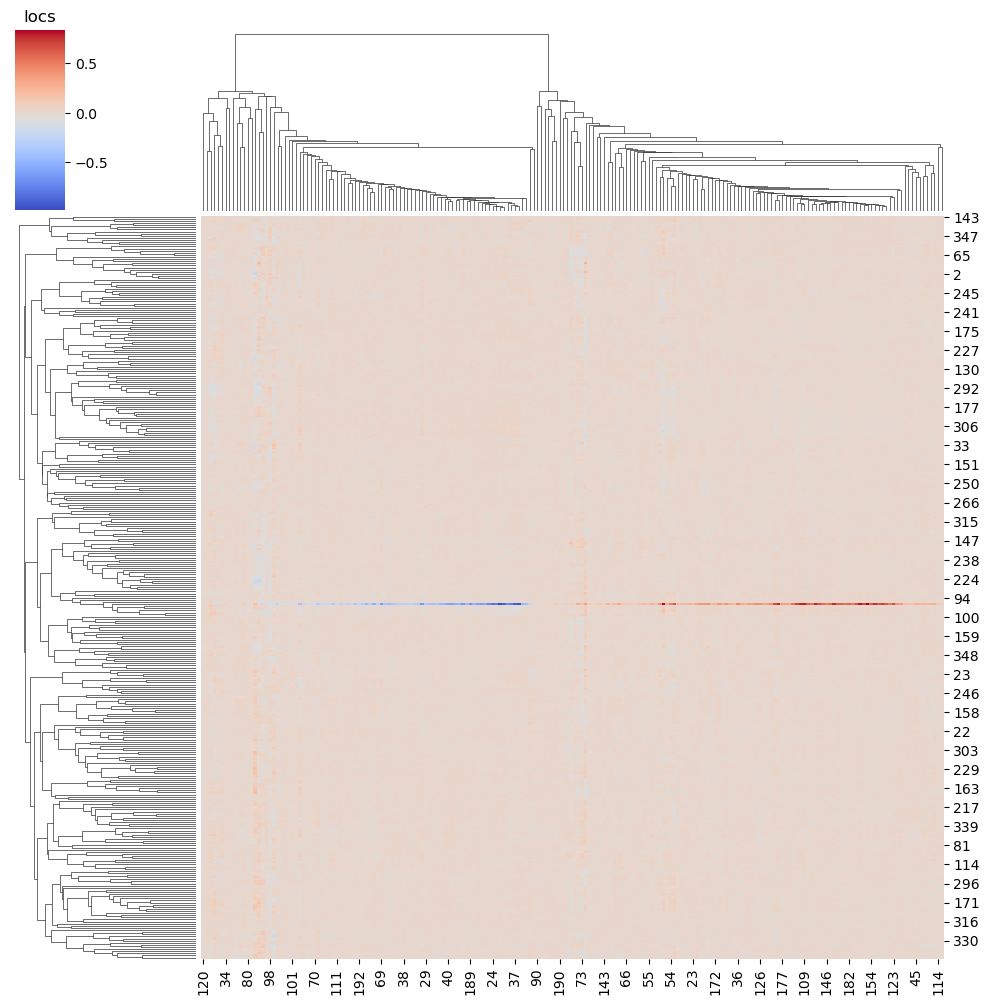

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


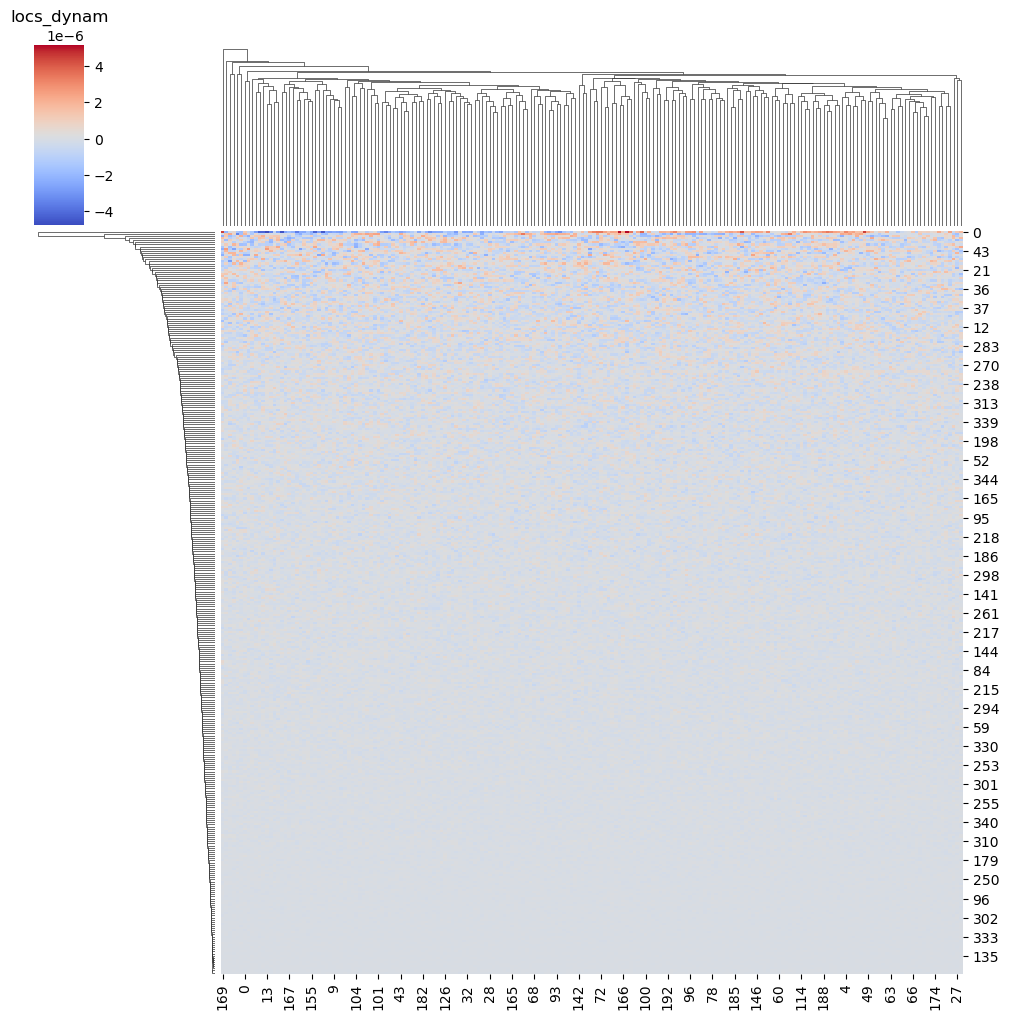

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


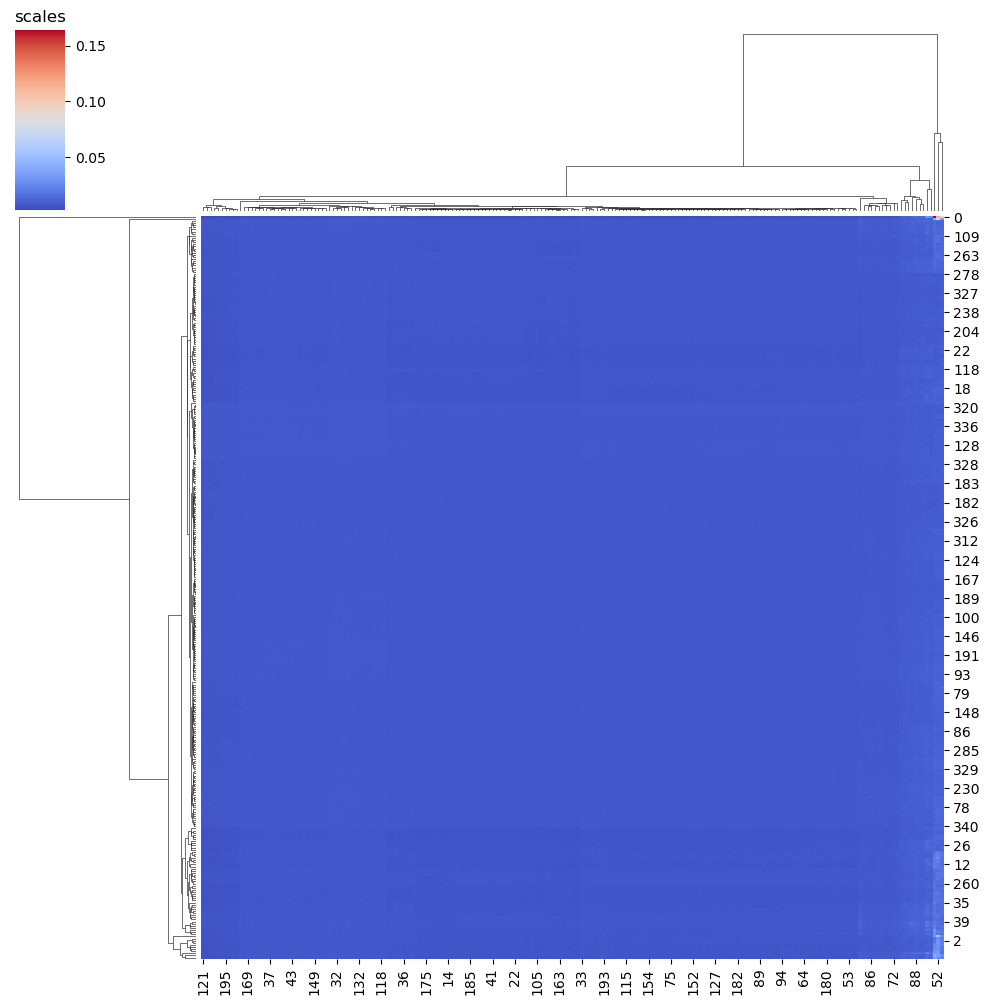

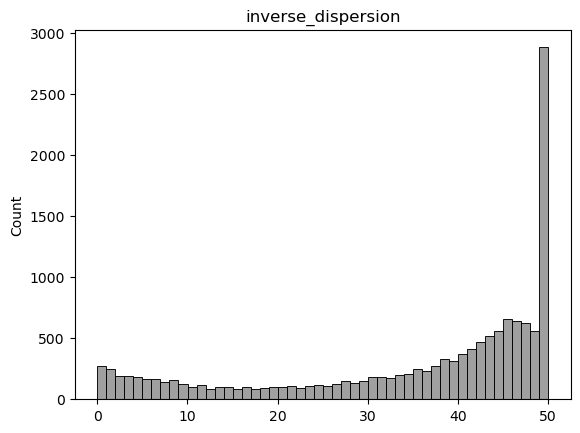

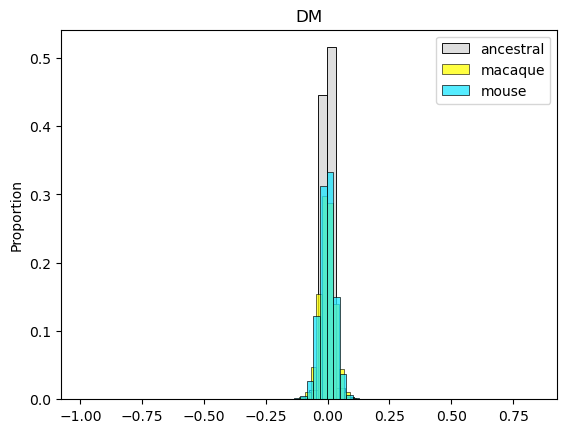

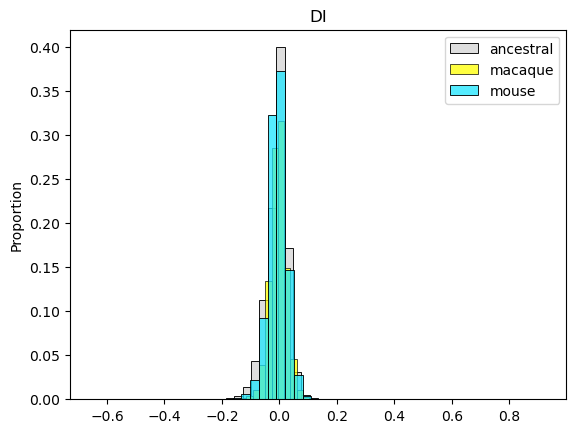

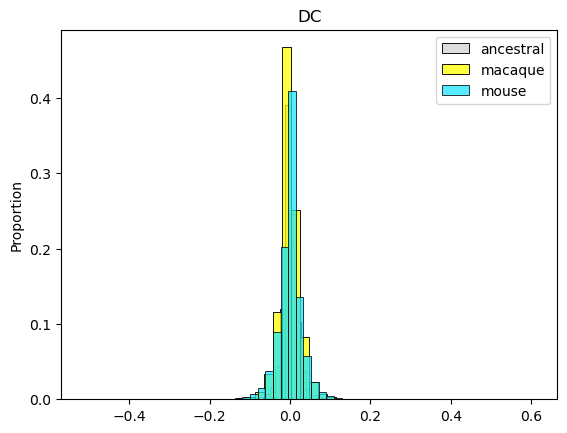

/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Matthew/code/scANTIPODE/antipode/plotting.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  batch_species=antipode_model.adata_manager.adata.obs.groupby(antipode_model.batch_key)['species'].value_counts().unstack().idxmax(axis=1).to_dict()


,0,1,batch_name,species
0,-0.339053,-0.085286,E10_hypothalamus_SAMN11975095,mouse
1,-0.287413,-0.032867,E11_hypothalamus_SAMN11975094,mouse
2,-0.259829,0.041239,E12_hypothalamus_SAMN11975071,mouse
3,-0.258851,0.029582,E12_hypothalamus_SAMN11975074,mouse
4,-0.264284,0.003155,E12_hypothalamus_SAMN11975077,mouse
...,...,...,...,...
278,0.655238,-0.209424,p0-WT2,mouse
279,0.661620,-0.219596,p0-WT3,mouse
280,0.592025,-0.297063,p0-WT4,mouse
281,0.860854,0.312552,p07_Cortex_SRR11947654,mouse


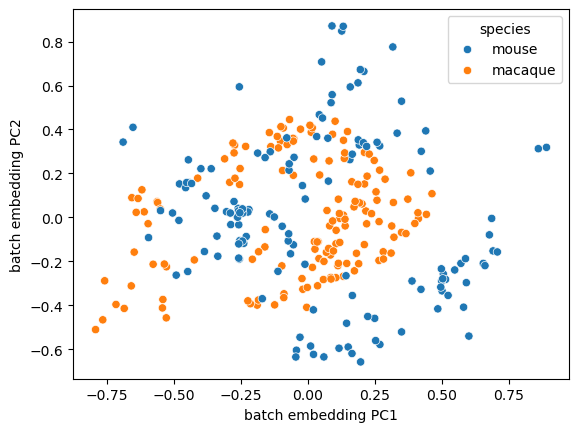

In [16]:
plot_loss(antipode_model.losses)
plot_gmm_heatmaps(antipode_model)
plot_d_hists(antipode_model)
plot_batch_embedding_pca(antipode_model)

INFO     Using cuda:0 for `pymde.preserve_neighbors`.                                                              


/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.11 /home/matthew.schmitz/Matthew/utils/miniforge3/e ...


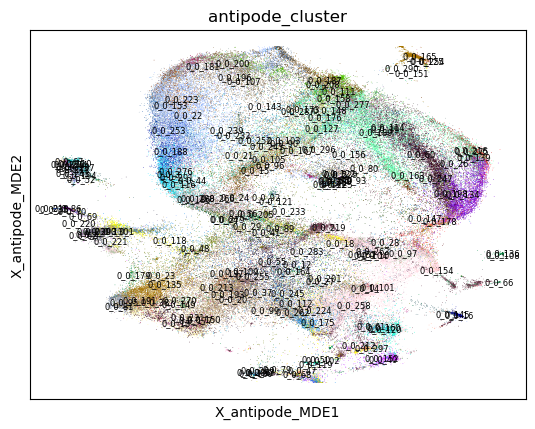

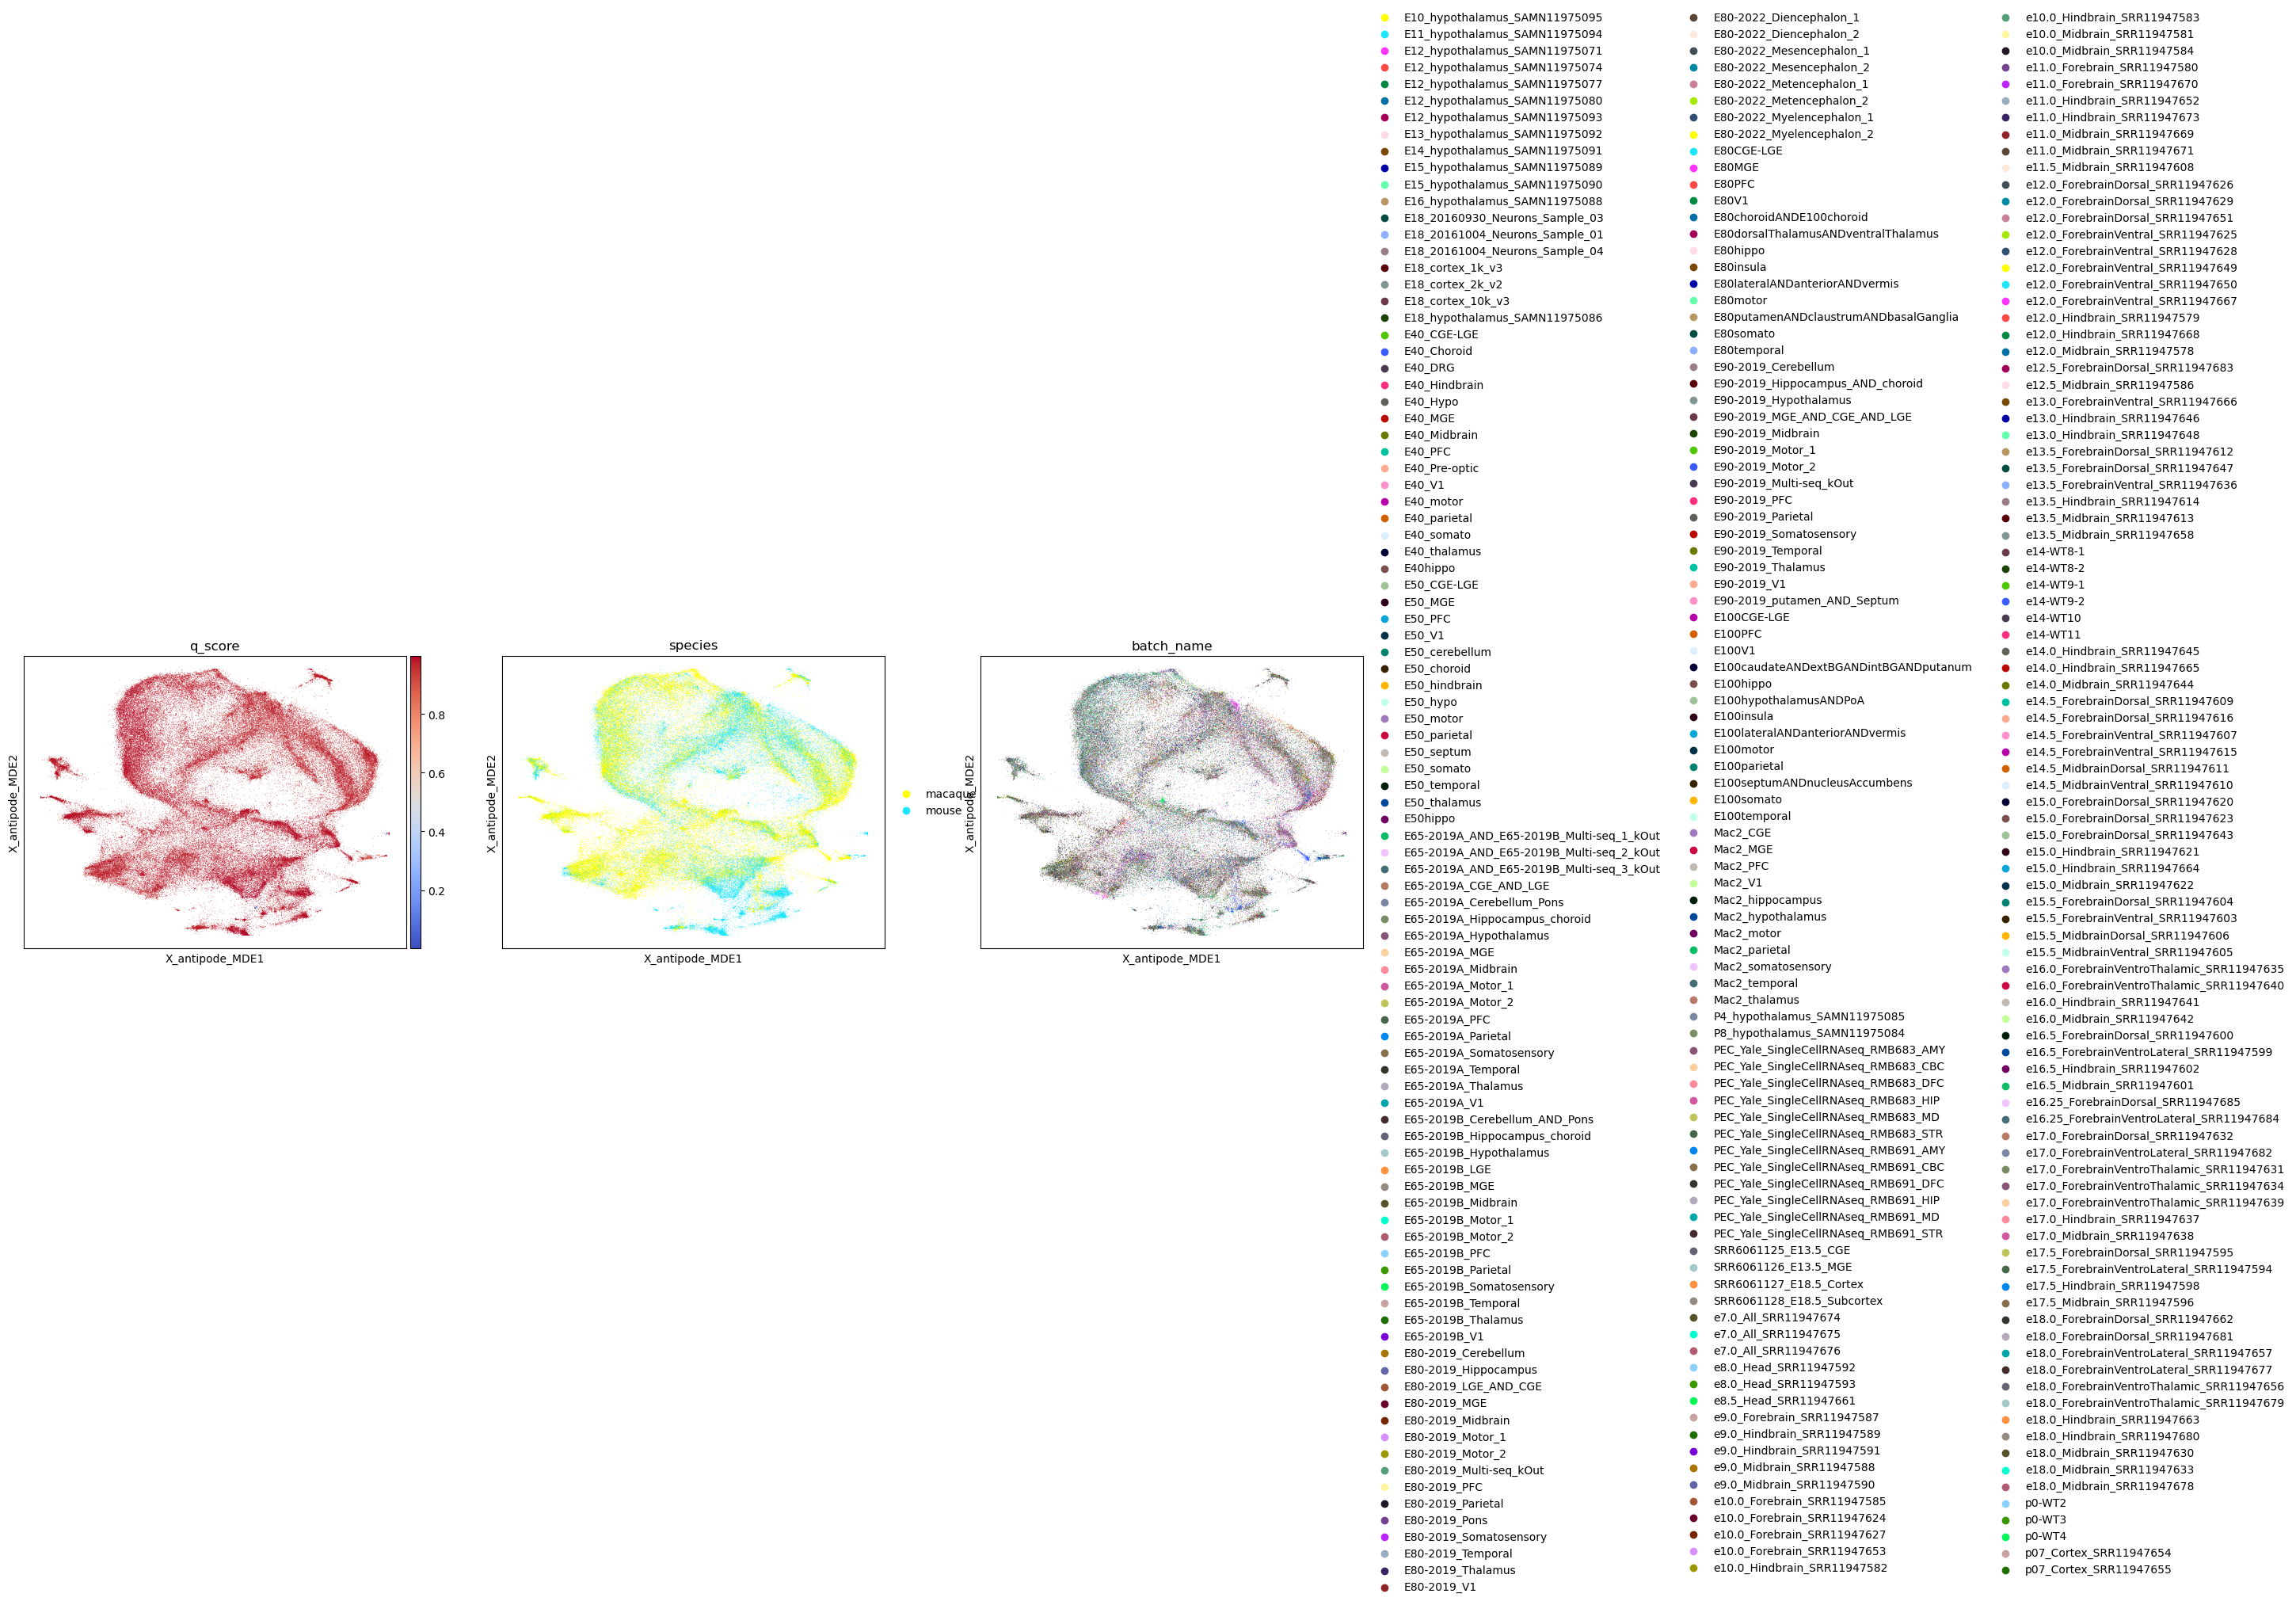

In [17]:
MDE_KEY = "X_antipode_MDE"
adata.obsm[MDE_KEY] = clip_latent_dimensions(scvi.model.utils.mde(adata.obsm['X_antipode'],init='random'),0.1)
sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=["antipode_cluster"],legend_fontsize=6,legend_fontweight='normal',
    legend_loc='on data',palette=sc.pl.palettes.godsnot_102
)

sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=['q_score',discov_key,batch_key],palette=sc.pl.palettes.godsnot_102,cmap='coolwarm'
)


In [18]:
!nvidia-smi
antipode_model.clear_cuda()
!nvidia-smi

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Thu Apr 11 15:17:48 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 545.23.08              Driver Version: 545.23.08    CUDA Version: 12.3     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100-PCIE-40GB          On  | 00000000:64:00.0 Off |                    0 |
| N/A   35C    P0              37W / 250W |   4253MiB / 40960MiB |      0%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

In [ ]:
antipode_model.save(os.path.join('/home/matthew.schmitz/Matthew/models/',model_tag),save_anndata=False,prefix='p1_')

In [ ]:
# del adata
# antipode_model=ANTIPODE.load(os.path.join('/home/matthew.schmitz/Matthew/models/',model_tag),prefix='p1_')
# antipode_model.train()
# adata=antipode_model.adata_manager.adata

# Training Phase 2: Intializing layered tree

In [ ]:
antipode_model.prepare_phase_2(epochs=2,device=device,dimension_reduction='X_antipode')

In [ ]:
antipode_model.train_phase(phase=2,max_steps=int(max_steps/2),print_every=10000,num_particles=1,device=device, max_learning_rate=1e-3, one_cycle_lr=True, batch_size=32,freeze_encoder=True)

In [ ]:
!nvidia-smi
antipode_model.clear_cuda()
!nvidia-smi

In [ ]:
antipode_model.store_outputs(device=device,prefix='')

In [ ]:
!nvidia-smi
antipode_model.clear_cuda()
!nvidia-smi

In [ ]:
plot_loss(antipode_model.losses)
plot_gmm_heatmaps(antipode_model)
plot_d_hists(antipode_model)
plot_tree_edge_weights(antipode_model)

In [ ]:
MDE_KEY = "X_antipode_MDE"
adata.obsm[MDE_KEY] = clip_latent_dimensions(scvi.model.utils.mde(adata.obsm['X_antipode'],init='random'),0.1)
sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=["antipode_cluster","kmeans"],legend_fontsize=6,legend_fontweight='normal',
    legend_loc='on data',palette=sc.pl.palettes.godsnot_102
)

sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=['q_score',discov_key,batch_key],palette=sc.pl.palettes.godsnot_102,cmap='coolwarm'
)

sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=[x for x in adata.obs.columns if 'psi' in x],
    cmap='coolwarm',
    legend_loc='on data'
)

sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=[x for x in adata.obs.columns if 'level' in x],
    palette=sc.pl.palettes.godsnot_102,
    legend_loc='on data'
)


In [ ]:
!nvidia-smi
antipode_model.clear_cuda()
!nvidia-smi

In [ ]:
antipode_model.save(os.path.join('/home/matthew.schmitz/Matthew/models/',model_tag),save_anndata=False,prefix='p2_')

In [ ]:
# del adata
# antipode_model=ANTIPODE.load(os.path.join('/home/matthew.schmitz/Matthew/models/',model_tag),prefix='p2_')
# antipode_model.train()
# adata=antipode_model.adata_manager.adata

In [ ]:
MDE_KEY = "X_antipode_MDE"
sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=["antipode_cluster"],legend_fontsize=6,legend_fontweight='normal',
    legend_loc='on data',palette=sc.pl.palettes.godsnot_102
)

sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=['q_score',discov_key,batch_key],palette=sc.pl.palettes.godsnot_102,cmap='coolwarm'
)

sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=[x for x in adata.obs.columns if 'psi' in x],
    cmap='coolwarm',
    legend_loc='on data'
)

sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=[x for x in adata.obs.columns if 'level' in x],
    palette=sc.pl.palettes.godsnot_102,
    legend_loc='on data'
)


# Training Phase 3: Refining the final tree

In [ ]:
antipode_model.train_phase(phase=3,max_steps=max_steps,print_every=10000,num_particles=3,device=device, max_learning_rate=5e-4, one_cycle_lr=True, steps=0, batch_size=32)

In [ ]:
!nvidia-smi
antipode_model.clear_cuda()
!nvidia-smi

In [ ]:
plot_loss(antipode_model.losses)

In [ ]:
antipode_model.store_outputs(device=device,prefix='')

In [ ]:
!nvidia-smi
antipode_model.clear_cuda()
!nvidia-smi

In [ ]:
plot_gmm_heatmaps(antipode_model)
plot_d_hists(antipode_model)
plot_tree_edge_weights(antipode_model)

In [ ]:
MDE_KEY = "X_antipode_MDE"
adata.obsm[MDE_KEY] = clip_latent_dimensions(scvi.model.utils.mde(adata.obsm['X_antipode'],init='random'),0.1)
sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=["antipode_cluster","kmeans"],legend_fontsize=6,legend_fontweight='normal',
    legend_loc='on data',palette=sc.pl.palettes.godsnot_102
)

sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=[x for x in adata.obs.columns if 'level' in x],
    palette=sc.pl.palettes.godsnot_102,
    legend_loc='on data'
)

sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=['q_score',discov_key,batch_key],palette=sc.pl.palettes.godsnot_102,cmap='coolwarm'
)

sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=[x for x in adata.obs.columns if 'psi' in x],
    cmap='coolwarm',
    legend_loc='on data'
)

In [ ]:
antipode_model.save(os.path.join('/home/matthew.schmitz/Matthew/models/',model_tag),save_anndata=True,prefix='p3_')

In [ ]:
# del adata
# antipode_model=ANTIPODE.load(os.path.join('/home/matthew.schmitz/Matthew/models/',model_tag),prefix='p3_')
# antipode_model.train()
# adata=antipode_model.adata_manager.adata

In [ ]:
seaborn.histplot(adata.obs['q_score'])

In [ ]:
random_choice=np.random.choice(adata.obs.index,size=100000,replace=False)
random_choice=np.where(adata.obs.index.isin(random_choice))[0]
xdata=adata[random_choice,:]
xdata=xdata.to_memory().copy()

In [ ]:
xdata.X=xdata.layers[layer_key]
sc.pp.normalize_per_cell(xdata)
sc.pp.log1p(xdata)
#sc.pp.scale(xdata,max_value=10)

gene_list=['RBFOX3','PDGFRA','AQP4','FOXJ1','AIF1','MOG','COL1A2','CD34','COL4A1','FOXG1','SATB2','RORB','SLC17A7','TLE4','FEZF2',
           'DLX2','PROX1','SCGN','NKX2-1','LHX6','SST','PVALB','CRABP1','MEIS2','TSHZ1','NPY','FOXP1','FOXP2','PDYN','PENK','ISL1',
           'MKI67','RPL7','RPS17','RPL13A','MEF2C',
           'HMX3','TH','LMX1A','TFAP2A','TFAP2B','RSPO1','NKX3-1','IGF1','ITPR2','OTX2','HOXB3','PAX1','PAX2','PAX3','PAX5','PAX6','PAX7','PAX8']
gene_list=[x for x in gene_list if x in xdata.var.index]
sc.pl.embedding(
    xdata,
    basis=MDE_KEY,
    color=gene_list,cmap='Purples',
    palette=sc.pl.palettes.godsnot_102,legend_fontsize=6,
    legend_loc='on data',use_raw=False
)
